Importing Libraries

In [ ]:
import urllib.request
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from scipy.stats import zscore
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, accuracy_score, classification_report, f1_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

import warnings
warnings.filterwarnings("ignore")

Loading dataset

In [ ]:
# Load the dataset
dataset_download_url = "https://www.kaggle.com/api/v1/datasets/download/ziya07/plant-health-data"

zip_path = "plant_health_data.zip"
urllib.request.urlretrieve(dataset_download_url, zip_path)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("plant_health_data")
plant_health_df = pd.read_csv('/content/plant_health_data/plant_health_data.csv')


Data Preprocessing

In [ ]:
# Encode plant health status
plant_health_status_map = {'Healthy': 0, 'Moderate Stress': 1, 'High Stress': 2}
plant_health_df['Health_Status_Encoded'] = plant_health_df['Plant_Health_Status'].map(plant_health_status_map)

In [ ]:
# Define features and target
X = plant_health_df.drop(columns=['Health_Status_Encoded', "Plant_Health_Status", "Timestamp", 'Plant_ID'])  # Features
y = plant_health_df['Health_Status_Encoded']  # Target

In [ ]:
X, y

(      Soil_Moisture  Ambient_Temperature  Soil_Temperature   Humidity  \
 0         27.521109            22.240245         21.900435  55.291904   
 1         14.835566            21.706763         18.680892  63.949181   
 2         17.086362            21.180946         15.392939  67.837956   
 3         15.336156            22.593302         22.778394  58.190811   
 4         39.822216            28.929001         18.100937  63.772036   
 ...             ...                  ...               ...        ...   
 1195      29.665780            27.605285         15.381699  54.668196   
 1196      15.490782            22.108112         15.221033  61.243143   
 1197      23.495723            21.680240         15.499764  40.693671   
 1198      30.971675            23.019488         21.934918  41.387107   
 1199      24.406357            25.724605         23.358573  47.505394   
 
       Light_Intensity   Soil_pH  Nitrogen_Level  Phosphorus_Level  \
 0          556.172805  5.581955       1

In [ ]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
# Apply StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Model Training and Evaluating



In [ ]:
# Initialize models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Naive Bayes": GaussianNB(),
    "Support Vector Machine": SVC(probability=True),  # probability=True needed for AUC
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier()
}



 Model: Logistic Regression
 Accuracy: 0.7500
 F1 Score: 0.7492
AUC Score: 0.9026

Classification Report:
                 precision    recall  f1-score   support

        Healthy       0.80      0.78      0.79        60
Moderate Stress       0.64      0.62      0.63        80
    High Stress       0.81      0.83      0.82       100

       accuracy                           0.75       240
      macro avg       0.75      0.75      0.75       240
   weighted avg       0.75      0.75      0.75       240



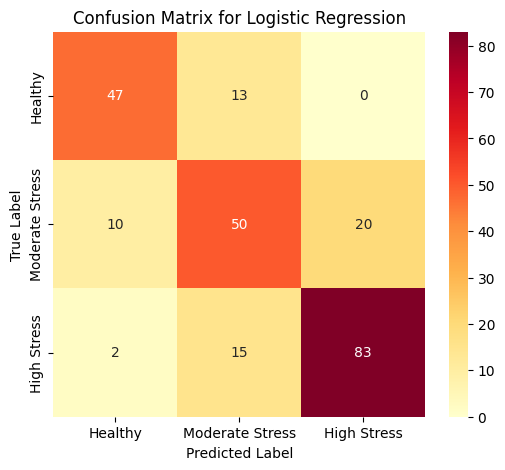


 Model: Naive Bayes
 Accuracy: 0.7833
 F1 Score: 0.7850
AUC Score: 0.9302

Classification Report:
                 precision    recall  f1-score   support

        Healthy       0.79      0.80      0.79        60
Moderate Stress       0.70      0.78      0.73        80
    High Stress       0.87      0.78      0.82       100

       accuracy                           0.78       240
      macro avg       0.78      0.79      0.78       240
   weighted avg       0.79      0.78      0.79       240



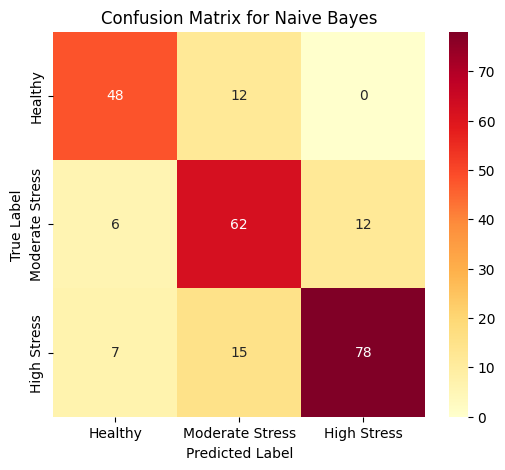


 Model: Support Vector Machine
 Accuracy: 0.7958
 F1 Score: 0.7962
AUC Score: 0.9432

Classification Report:
                 precision    recall  f1-score   support

        Healthy       0.84      0.80      0.82        60
Moderate Stress       0.70      0.71      0.70        80
    High Stress       0.85      0.86      0.86       100

       accuracy                           0.80       240
      macro avg       0.80      0.79      0.79       240
   weighted avg       0.80      0.80      0.80       240



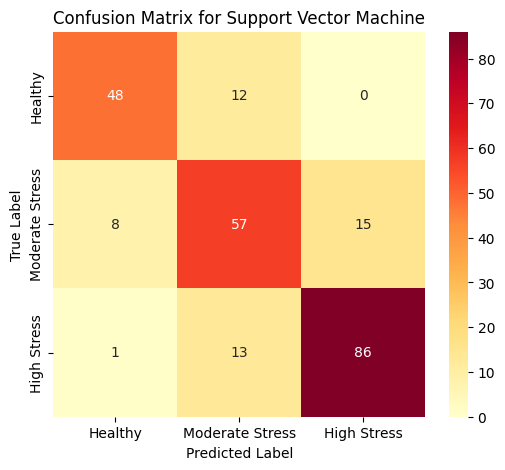


 Model: K-Nearest Neighbors
 Accuracy: 0.6417
 F1 Score: 0.6516
AUC Score: 0.8100

Classification Report:
                 precision    recall  f1-score   support

        Healthy       0.57      0.65      0.61        60
Moderate Stress       0.49      0.57      0.53        80
    High Stress       0.88      0.69      0.78       100

       accuracy                           0.64       240
      macro avg       0.65      0.64      0.64       240
   weighted avg       0.68      0.64      0.65       240



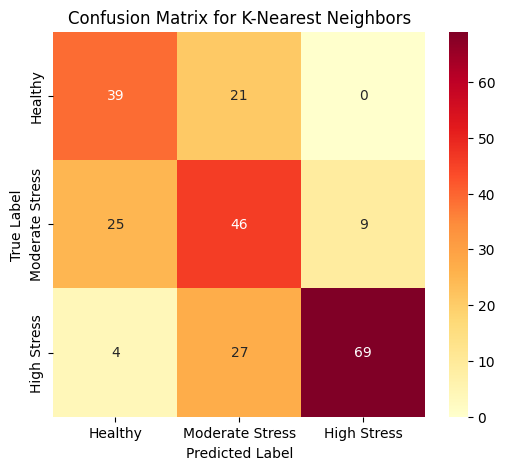


 Model: Decision Tree
 Accuracy: 0.9917
 F1 Score: 0.9917
AUC Score: 0.9935

Classification Report:
                 precision    recall  f1-score   support

        Healthy       1.00      0.98      0.99        60
Moderate Stress       0.98      1.00      0.99        80
    High Stress       1.00      0.99      0.99       100

       accuracy                           0.99       240
      macro avg       0.99      0.99      0.99       240
   weighted avg       0.99      0.99      0.99       240



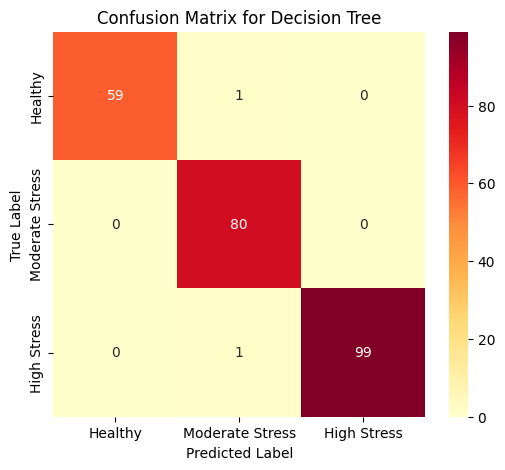


 Model: Random Forest
 Accuracy: 0.9875
 F1 Score: 0.9875
AUC Score: 0.9996

Classification Report:
                 precision    recall  f1-score   support

        Healthy       1.00      0.98      0.99        60
Moderate Stress       0.98      0.99      0.98        80
    High Stress       0.99      0.99      0.99       100

       accuracy                           0.99       240
      macro avg       0.99      0.99      0.99       240
   weighted avg       0.99      0.99      0.99       240



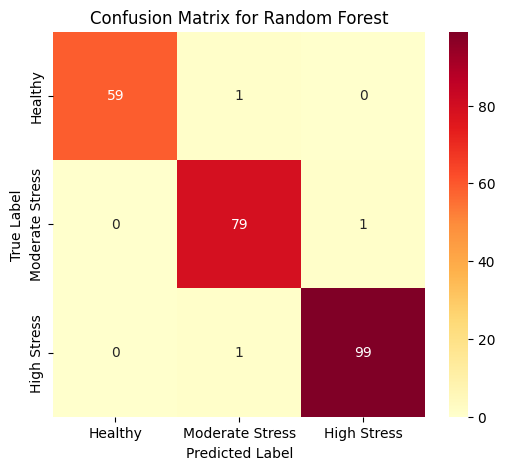


 Model: Gradient Boosting
 Accuracy: 0.9875
 F1 Score: 0.9875
AUC Score: 0.9940

Classification Report:
                 precision    recall  f1-score   support

        Healthy       1.00      0.98      0.99        60
Moderate Stress       0.98      0.99      0.98        80
    High Stress       0.99      0.99      0.99       100

       accuracy                           0.99       240
      macro avg       0.99      0.99      0.99       240
   weighted avg       0.99      0.99      0.99       240



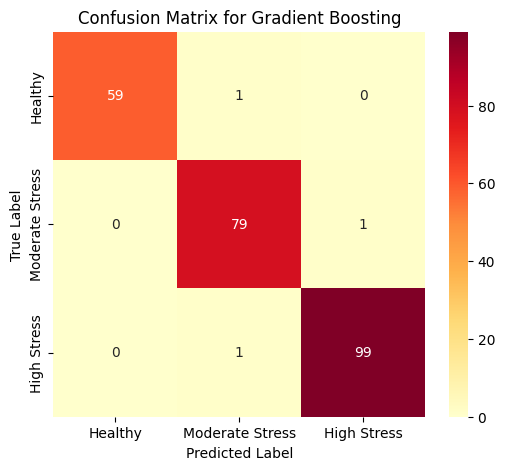

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, f1_score

# Storage for model evaluation results
model_metrics = []

# Train, predict, and evaluate each model
for name, clf in models.items():
    clf.fit(X_train_scaled, y_train)
    y_pred = clf.predict(X_test_scaled)

    # Basic metrics
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')

    # AUC (if possible)
    if hasattr(clf, "predict_proba"):
        y_proba = clf.predict_proba(X_test_scaled)
        auc = roc_auc_score(y_test, y_proba, multi_class='ovr')
    else:
        auc = None

    # Classification report and confusion matrix (specific per model)
    class_report = classification_report(y_test, y_pred, target_names=['Healthy', 'Moderate Stress', 'High Stress'])
    conf_matrix = confusion_matrix(y_test, y_pred)

    # Store all metrics
    model_metrics.append({
        "Model": name,
        "Accuracy": accuracy,
        "F1 Score": f1,
        "AUC": auc,
        "Classification Report": class_report,
        "Confusion Matrix": conf_matrix
    })

# Show all results
for res in model_metrics:
    print(f"\n Model: {res['Model']}")
    print(f" Accuracy: {res['Accuracy']:.4f}")
    print(f" F1 Score: {res['F1 Score']:.4f}")
    if res["AUC"] is not None:
        print(f"AUC Score: {res['AUC']:.4f}")

    print("\nClassification Report:")
    print(res["Classification Report"])

    # Visualize Confusion Matrix
    plt.figure(figsize=(6, 5))
    sns.heatmap(res["Confusion Matrix"], annot=True, fmt='d', cmap='YlOrRd',
                xticklabels=['Healthy', 'Moderate Stress', 'High Stress'],
                yticklabels=['Healthy', 'Moderate Stress', 'High Stress'])
    plt.title(f'Confusion Matrix for {res["Model"]}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()


In [ ]:
# Define simple weights for each metric
weight_auc = 0.4
weight_f1 = 0.4
weight_acc = 0.2

# Calculate composite score for each model
for model in model_metrics:
    auc = model["AUC"] if model["AUC"] is not None else 0
    f1 = model["F1 Score"]
    acc = model["Accuracy"]

    # Weighted sum
    model["Score"] = (
        weight_auc * auc +
        weight_f1 * f1 +
        weight_acc * acc
    )

# Rank models by score
ranked_models = sorted(model_metrics, key=lambda m: m["Score"], reverse=True)

# Display the ranked models
print("\n Ranked Models:")
for i, m in enumerate(ranked_models, start=1):
    print(f"{i}. {m['Model']} - Score: {m['Score']:.3f}")

# Best model
print(f"\n Best Model: {ranked_models[0]['Model']} with Score: {ranked_models[0]['Score']:.3f}")



 Ranked Models:
1. Decision Tree - Score: 0.992
2. Random Forest - Score: 0.992
3. Gradient Boosting - Score: 0.990
4. Support Vector Machine - Score: 0.855
5. Naive Bayes - Score: 0.843
6. Logistic Regression - Score: 0.811
7. K-Nearest Neighbors - Score: 0.713

 Best Model: Decision Tree with Score: 0.992


Retraining the classifiers with Feature Selection algorithms


 Training Logistic Regression

 Using Filter FS (SelectKBest):
 Selected Features (Filter FS): ['Soil_Moisture', 'Nitrogen_Level', 'Potassium_Level']

 Evaluation for Logistic Regression using Filter FS:
 Accuracy: 0.7458 |  F1 Score: 0.7456 |  AUC: 0.8047

 Classification Report:
                 precision    recall  f1-score   support

        Healthy       0.78      0.75      0.76        60
Moderate Stress       0.64      0.64      0.64        80
    High Stress       0.81      0.83      0.82       100

       accuracy                           0.75       240
      macro avg       0.74      0.74      0.74       240
   weighted avg       0.75      0.75      0.75       240



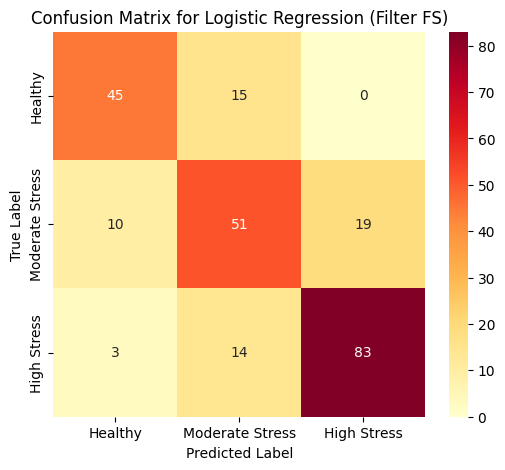


 Using Wrapper FS (RFE):
Selected Features (Wrapper FS): ['Soil_Moisture', 'Nitrogen_Level', 'Phosphorus_Level']

 Evaluation for Logistic Regression using Wrapper FS:
 Accuracy: 0.7542 |  F1 Score: 0.7541 |  AUC: 0.8101

 Classification Report:
                 precision    recall  f1-score   support

        Healthy       0.82      0.75      0.78        60
Moderate Stress       0.64      0.65      0.65        80
    High Stress       0.81      0.84      0.82       100

       accuracy                           0.75       240
      macro avg       0.76      0.75      0.75       240
   weighted avg       0.76      0.75      0.75       240



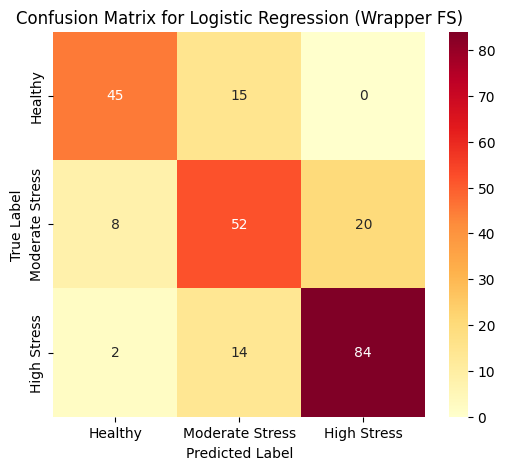


 Using Embedded FS:
 Selected Features (Embedded FS): ['Soil_Moisture', 'Nitrogen_Level']

 Evaluation for Logistic Regression using Embedded FS:
 Accuracy: 0.7458 |  F1 Score: 0.7459 |  AUC: 0.8041

 Classification Report:
                 precision    recall  f1-score   support

        Healthy       0.82      0.75      0.78        60
Moderate Stress       0.63      0.64      0.63        80
    High Stress       0.80      0.83      0.81       100

       accuracy                           0.75       240
      macro avg       0.75      0.74      0.74       240
   weighted avg       0.75      0.75      0.75       240



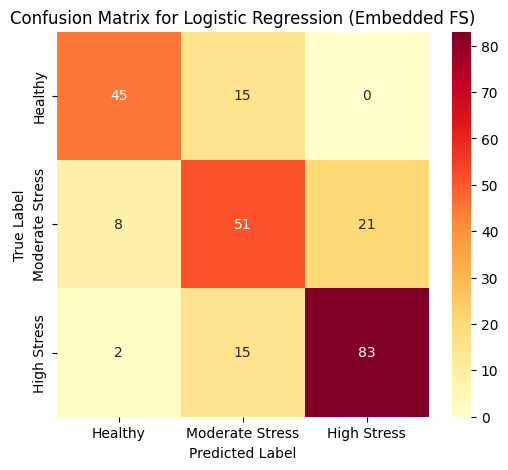


 Training Naive Bayes

 Using Filter FS (SelectKBest):
 Selected Features (Filter FS): ['Soil_Moisture', 'Nitrogen_Level', 'Potassium_Level']

 Evaluation for Naive Bayes using Filter FS:
 Accuracy: 0.7708 |  F1 Score: 0.7725 |  AUC: 0.8277

 Classification Report:
                 precision    recall  f1-score   support

        Healthy       0.78      0.78      0.78        60
Moderate Stress       0.68      0.75      0.71        80
    High Stress       0.85      0.78      0.81       100

       accuracy                           0.77       240
      macro avg       0.77      0.77      0.77       240
   weighted avg       0.78      0.77      0.77       240



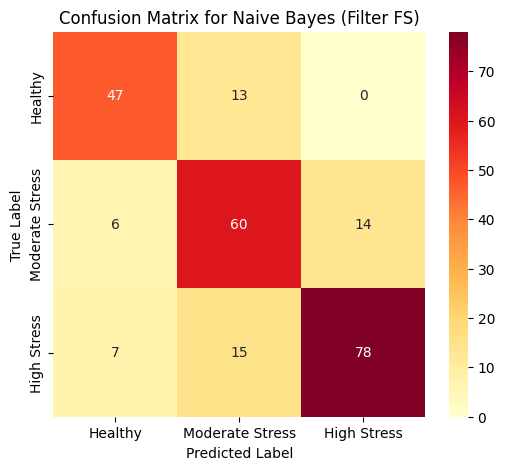


 Using Embedded FS:
 Embedded FS not applied for Naive Bayes: Naive Bayes does not support embedded FS

 Training Support Vector Machine

 Using Filter FS (SelectKBest):
 Selected Features (Filter FS): ['Soil_Moisture', 'Nitrogen_Level', 'Potassium_Level']

 Evaluation for Support Vector Machine using Filter FS:
 Accuracy: 0.9375 |  F1 Score: 0.9381 |  AUC: 0.9499

 Classification Report:
                 precision    recall  f1-score   support

        Healthy       1.00      0.88      0.94        60
Moderate Stress       0.87      0.96      0.91        80
    High Stress       0.97      0.95      0.96       100

       accuracy                           0.94       240
      macro avg       0.94      0.93      0.94       240
   weighted avg       0.94      0.94      0.94       240



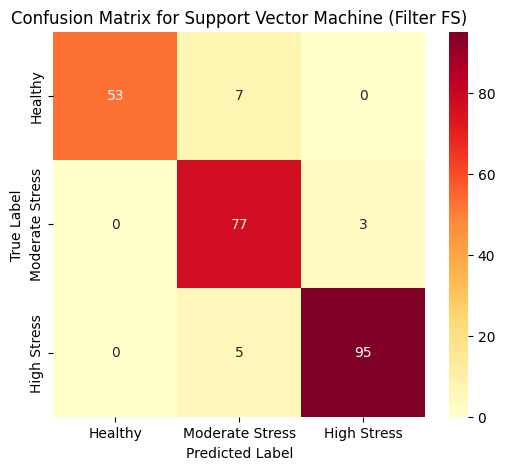


 Using Embedded FS:
 Embedded FS not applied for Support Vector Machine: Support Vector Machine does not support embedded FS

 Training K-Nearest Neighbors

 Using Filter FS (SelectKBest):
 Selected Features (Filter FS): ['Soil_Moisture', 'Nitrogen_Level', 'Potassium_Level']

 Evaluation for K-Nearest Neighbors using Filter FS:
 Accuracy: 0.9125 |  F1 Score: 0.9128 |  AUC: 0.9322

 Classification Report:
                 precision    recall  f1-score   support

        Healthy       0.95      0.90      0.92        60
Moderate Stress       0.86      0.89      0.87        80
    High Stress       0.94      0.94      0.94       100

       accuracy                           0.91       240
      macro avg       0.91      0.91      0.91       240
   weighted avg       0.91      0.91      0.91       240



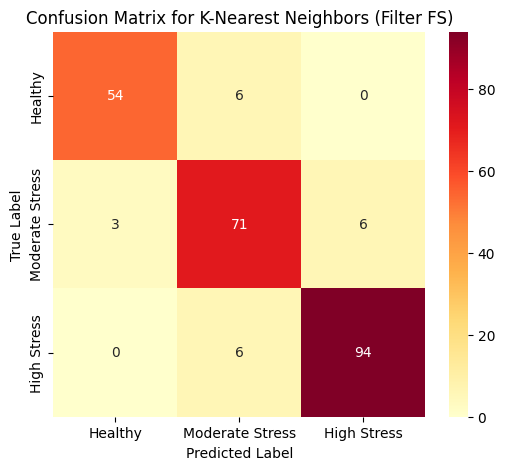


 Using Embedded FS:
 Embedded FS not applied for K-Nearest Neighbors: K-Nearest Neighbors does not support embedded FS

 Training Decision Tree

 Using Filter FS (SelectKBest):
 Selected Features (Filter FS): ['Soil_Moisture', 'Nitrogen_Level', 'Potassium_Level']

 Evaluation for Decision Tree using Filter FS:
 Accuracy: 0.9917 |  F1 Score: 0.9917 |  AUC: 0.9935

 Classification Report:
                 precision    recall  f1-score   support

        Healthy       1.00      0.98      0.99        60
Moderate Stress       0.98      1.00      0.99        80
    High Stress       1.00      0.99      0.99       100

       accuracy                           0.99       240
      macro avg       0.99      0.99      0.99       240
   weighted avg       0.99      0.99      0.99       240



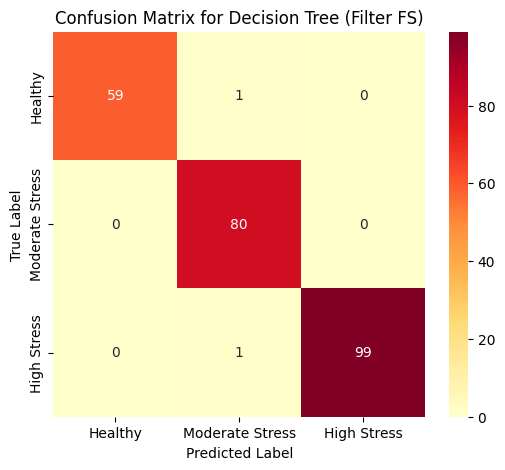


 Using Wrapper FS (RFE):
Selected Features (Wrapper FS): ['Soil_Moisture', 'Nitrogen_Level', 'Phosphorus_Level']

 Evaluation for Decision Tree using Wrapper FS:
 Accuracy: 0.9917 |  F1 Score: 0.9917 |  AUC: 0.9935

 Classification Report:
                 precision    recall  f1-score   support

        Healthy       1.00      0.98      0.99        60
Moderate Stress       0.98      1.00      0.99        80
    High Stress       1.00      0.99      0.99       100

       accuracy                           0.99       240
      macro avg       0.99      0.99      0.99       240
   weighted avg       0.99      0.99      0.99       240



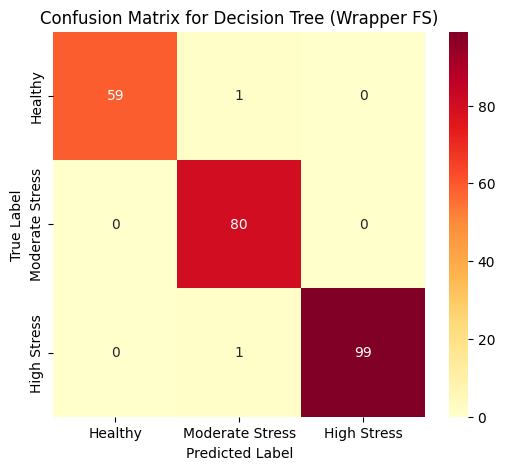


 Using Embedded FS:
 Selected Features (Embedded FS): ['Soil_Moisture', 'Ambient_Temperature', 'Soil_Temperature', 'Humidity', 'Light_Intensity', 'Soil_pH', 'Nitrogen_Level', 'Phosphorus_Level', 'Potassium_Level', 'Chlorophyll_Content', 'Electrochemical_Signal']

 Evaluation for Decision Tree using Embedded FS:
 Accuracy: 0.9917 |  F1 Score: 0.9917 |  AUC: 0.9935

 Classification Report:
                 precision    recall  f1-score   support

        Healthy       1.00      0.98      0.99        60
Moderate Stress       0.98      1.00      0.99        80
    High Stress       1.00      0.99      0.99       100

       accuracy                           0.99       240
      macro avg       0.99      0.99      0.99       240
   weighted avg       0.99      0.99      0.99       240



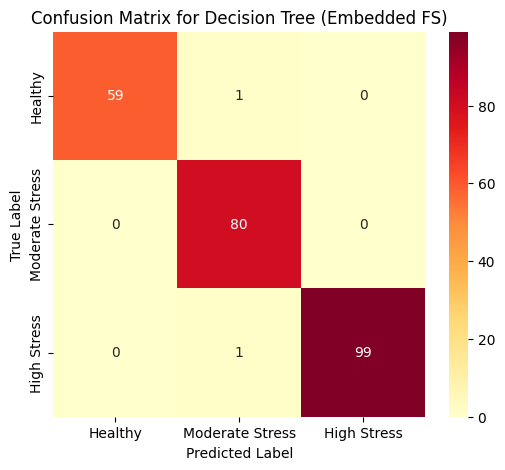


 Training Random Forest

 Using Filter FS (SelectKBest):
 Selected Features (Filter FS): ['Soil_Moisture', 'Nitrogen_Level', 'Potassium_Level']

 Evaluation for Random Forest using Filter FS:
 Accuracy: 0.9875 |  F1 Score: 0.9875 |  AUC: 0.9902

 Classification Report:
                 precision    recall  f1-score   support

        Healthy       1.00      0.98      0.99        60
Moderate Stress       0.98      0.99      0.98        80
    High Stress       0.99      0.99      0.99       100

       accuracy                           0.99       240
      macro avg       0.99      0.99      0.99       240
   weighted avg       0.99      0.99      0.99       240



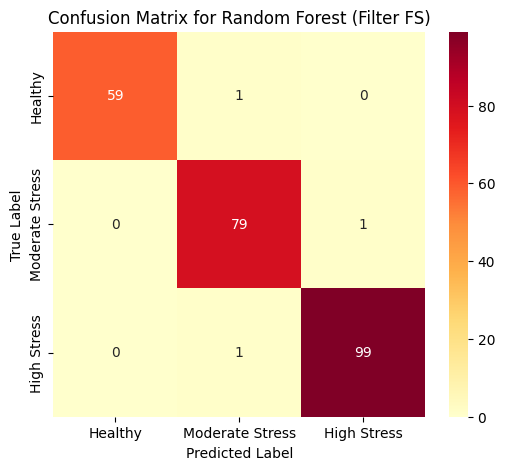


 Using Wrapper FS (RFE):
Selected Features (Wrapper FS): ['Soil_Moisture', 'Soil_pH', 'Nitrogen_Level']

 Evaluation for Random Forest using Wrapper FS:
 Accuracy: 0.9917 |  F1 Score: 0.9917 |  AUC: 0.9940

 Classification Report:
                 precision    recall  f1-score   support

        Healthy       1.00      1.00      1.00        60
Moderate Stress       0.99      0.99      0.99        80
    High Stress       0.99      0.99      0.99       100

       accuracy                           0.99       240
      macro avg       0.99      0.99      0.99       240
   weighted avg       0.99      0.99      0.99       240



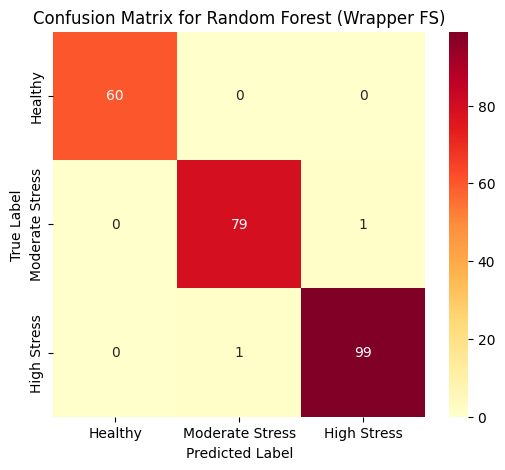


 Using Embedded FS:
 Selected Features (Embedded FS): ['Soil_Moisture', 'Nitrogen_Level', 'Potassium_Level']

 Evaluation for Random Forest using Embedded FS:
 Accuracy: 0.9875 |  F1 Score: 0.9875 |  AUC: 0.9902

 Classification Report:
                 precision    recall  f1-score   support

        Healthy       1.00      0.98      0.99        60
Moderate Stress       0.98      0.99      0.98        80
    High Stress       0.99      0.99      0.99       100

       accuracy                           0.99       240
      macro avg       0.99      0.99      0.99       240
   weighted avg       0.99      0.99      0.99       240



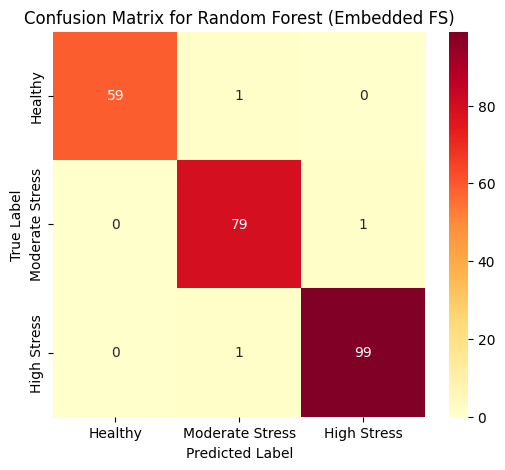


 Training Gradient Boosting

 Using Filter FS (SelectKBest):
 Selected Features (Filter FS): ['Soil_Moisture', 'Nitrogen_Level', 'Potassium_Level']

 Evaluation for Gradient Boosting using Filter FS:
 Accuracy: 0.9875 |  F1 Score: 0.9875 |  AUC: 0.9902

 Classification Report:
                 precision    recall  f1-score   support

        Healthy       1.00      0.98      0.99        60
Moderate Stress       0.98      0.99      0.98        80
    High Stress       0.99      0.99      0.99       100

       accuracy                           0.99       240
      macro avg       0.99      0.99      0.99       240
   weighted avg       0.99      0.99      0.99       240



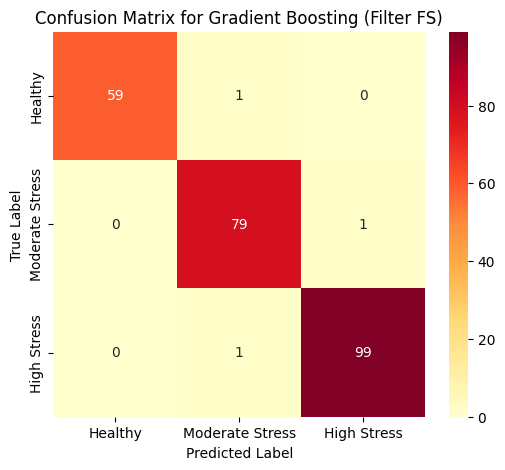


 Using Wrapper FS (RFE):
Selected Features (Wrapper FS): ['Soil_Moisture', 'Nitrogen_Level', 'Electrochemical_Signal']

 Evaluation for Gradient Boosting using Wrapper FS:
 Accuracy: 0.9875 |  F1 Score: 0.9875 |  AUC: 0.9902

 Classification Report:
                 precision    recall  f1-score   support

        Healthy       1.00      0.98      0.99        60
Moderate Stress       0.98      0.99      0.98        80
    High Stress       0.99      0.99      0.99       100

       accuracy                           0.99       240
      macro avg       0.99      0.99      0.99       240
   weighted avg       0.99      0.99      0.99       240



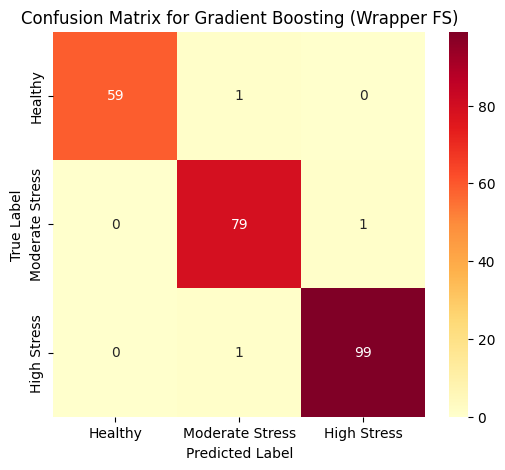


 Using Embedded FS:
 Selected Features (Embedded FS): ['Soil_Moisture', 'Soil_pH', 'Nitrogen_Level']

 Evaluation for Gradient Boosting using Embedded FS:
 Accuracy: 0.9875 |  F1 Score: 0.9875 |  AUC: 0.9902

 Classification Report:
                 precision    recall  f1-score   support

        Healthy       1.00      0.98      0.99        60
Moderate Stress       0.98      0.99      0.98        80
    High Stress       0.99      0.99      0.99       100

       accuracy                           0.99       240
      macro avg       0.99      0.99      0.99       240
   weighted avg       0.99      0.99      0.99       240



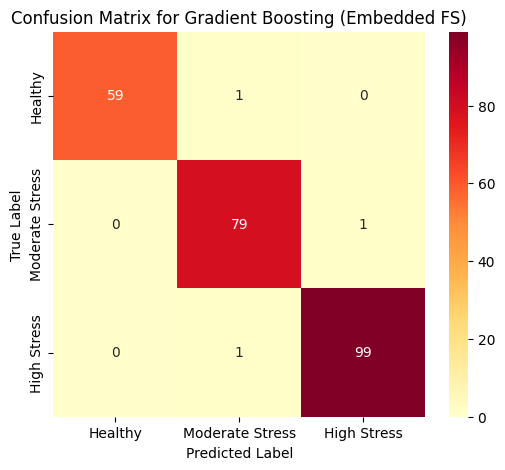


Ranked Models Based on Feature Selection Performance:
1. Random Forest (FS: Wrapper FS) - Score: 0.993
   Selected Features: ['Soil_Moisture', 'Soil_pH', 'Nitrogen_Level']
2. Decision Tree (FS: Filter FS) - Score: 0.992
   Selected Features: ['Soil_Moisture', 'Nitrogen_Level', 'Potassium_Level']
3. Gradient Boosting (FS: Filter FS) - Score: 0.989
   Selected Features: ['Soil_Moisture', 'Nitrogen_Level', 'Potassium_Level']
4. Support Vector Machine (FS: Filter FS) - Score: 0.943
   Selected Features: ['Soil_Moisture', 'Nitrogen_Level', 'Potassium_Level']
5. K-Nearest Neighbors (FS: Filter FS) - Score: 0.920
   Selected Features: ['Soil_Moisture', 'Nitrogen_Level', 'Potassium_Level']
6. Naive Bayes (FS: Filter FS) - Score: 0.794
   Selected Features: ['Soil_Moisture', 'Nitrogen_Level', 'Potassium_Level']
7. Logistic Regression (FS: Wrapper FS) - Score: 0.776
   Selected Features: ['Soil_Moisture', 'Nitrogen_Level', 'Phosphorus_Level']

 Best Model: Random Forest using Wrapper FS with Sc

In [ ]:
from sklearn.feature_selection import SelectKBest, f_classif, RFE, SelectFromModel
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report, confusion_matrix
from sklearn.exceptions import NotFittedError


# Feature scaling
scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns)
X_test = pd.DataFrame(scaler.transform(X_test), columns=X.columns)

# Filter method using SelectKBest
def filter_method(X_train, y_train, X_test, k=3):
    selector = SelectKBest(score_func=f_classif, k=k)
    X_train_selected = selector.fit_transform(X_train, y_train)
    X_test_selected = selector.transform(X_test)
    selected_features = X_train.columns[selector.get_support()]
    return X_train_selected, X_test_selected, selected_features

# Wrapper method using RFE
def wrapper_method(X_train, y_train, X_test, model, n_features_to_select=3):
    rfe = RFE(estimator=model, n_features_to_select=n_features_to_select)
    X_train_selected = rfe.fit_transform(X_train, y_train)
    X_test_selected = rfe.transform(X_test)
    selected_features = X_train.columns[rfe.get_support()]
    return X_train_selected, X_test_selected, selected_features

# Evaluation results storage
fs_model_metrics = []

# Evaluation function

def evaluate_model_and_store(y_true, y_pred, clf_name, fs_method, selected_features):
    accuracy = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='weighted')
    try:
        auc = roc_auc_score(pd.get_dummies(y_true), pd.get_dummies(y_pred), multi_class='ovr')
    except:
        auc = 0

    fs_model_metrics.append({
        "Model": clf_name,
        "FS Method": fs_method,
        "Selected Features": selected_features,
        "Accuracy": accuracy,
        "F1 Score": f1,
        "AUC": auc,
    })

    print(f"\n Evaluation for {clf_name} using {fs_method}:")
    print(f" Accuracy: {accuracy:.4f} |  F1 Score: {f1:.4f} |  AUC: {auc:.4f}")
    print("\n Classification Report:")
    print(classification_report(y_true, y_pred, target_names=['Healthy', 'Moderate Stress', 'High Stress']))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd',
                xticklabels=['Healthy', 'Moderate Stress', 'High Stress'],
                yticklabels=['Healthy', 'Moderate Stress', 'High Stress'])
    plt.title(f'Confusion Matrix for {clf_name} ({fs_method})')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

# Models compatible with RFE
rfe_compatible = ["Logistic Regression", "Decision Tree", "Random Forest", "Gradient Boosting"]

# Main training and evaluation loop
for clf_name, clf in models.items():
    print(f"\n Training {clf_name}")

    # Filter FS
    print("\n Using Filter FS (SelectKBest):")
    X_train_filter, X_test_filter, selected_filter_features = filter_method(X_train, y_train, X_test, k=3)
    print(f" Selected Features (Filter FS): {selected_filter_features.tolist()}")
    clf.fit(X_train_filter, y_train)
    y_pred_filter = clf.predict(X_test_filter)
    evaluate_model_and_store(y_test, y_pred_filter, clf_name, "Filter FS", selected_filter_features.tolist())

    # Wrapper FS
    if clf_name in rfe_compatible:
        print("\n Using Wrapper FS (RFE):")
        try:
            X_train_wrapper, X_test_wrapper, selected_wrapper_features = wrapper_method(X_train, y_train, X_test, clf, n_features_to_select=3)
            print(f"Selected Features (Wrapper FS): {selected_wrapper_features.tolist()}")
            clf.fit(X_train_wrapper, y_train)
            y_pred_wrapper = clf.predict(X_test_wrapper)
            evaluate_model_and_store(y_test, y_pred_wrapper, clf_name, "Wrapper FS", selected_wrapper_features.tolist())
        except ValueError as e:
            print(f" Wrapper FS not applied for {clf_name}: {e}")

    # Embedded FS
    print("\n Using Embedded FS:")
    try:
        clf.fit(X_train, y_train)
        if hasattr(clf, "feature_importances_"):
            importances = clf.feature_importances_
        elif hasattr(clf, "coef_"):
            importances = abs(clf.coef_).flatten()
        else:
            raise ValueError(f"{clf_name} does not support embedded FS")

        importance_threshold = sorted(importances, reverse=True)[2]
        selector = SelectFromModel(clf, threshold=importance_threshold, prefit=True)
        X_train_embed = selector.transform(X_train)
        X_test_embed = selector.transform(X_test)
        selected_embed_features = X_train.columns[selector.get_support()]
        print(f" Selected Features (Embedded FS): {selected_embed_features.tolist()}")

        clf.fit(X_train_embed, y_train)
        y_pred_embed = clf.predict(X_test_embed)
        evaluate_model_and_store(y_test, y_pred_embed, clf_name, "Embedded FS", selected_embed_features.tolist())

    except (ValueError, NotFittedError) as e:
        print(f" Embedded FS not applied for {clf_name}: {e}")

# Ranking FS models
weight_auc = 0.4
weight_f1 = 0.4
weight_acc = 0.2

best_fs_models = {}
for entry in fs_model_metrics:
    name = entry['Model']
    score = (
        weight_auc * (entry['AUC'] if entry['AUC'] is not None else 0) +
        weight_f1 * entry['F1 Score'] +
        weight_acc * entry['Accuracy']
    )
    entry['Score'] = score

    if name not in best_fs_models or score > best_fs_models[name]['Score']:
        best_fs_models[name] = entry

ranked_fs_models = sorted(best_fs_models.values(), key=lambda x: x['Score'], reverse=True)

print("\nRanked Models Based on Feature Selection Performance:")
for i, model in enumerate(ranked_fs_models, start=1):
    print(f"{i}. {model['Model']} (FS: {model['FS Method']}) - Score: {model['Score']:.3f}")
    print(f"   Selected Features: {model['Selected Features']}")

best = ranked_fs_models[0]
print(f"\n Best Model: {best['Model']} using {best['FS Method']} with Score: {best['Score']:.3f}")
print(f"   Selected Features: {best['Selected Features']}")


Saving the best model trained with FS

In [ ]:
import joblib


best = ranked_fs_models[0]
best_model_name = best['Model']  # The name of the best model (e.g., 'RandomForestClassifier')

# Extract the trained model from `models` dictionary
best_trained_model = models[best_model_name]

# Get the selected features for the best model
selected_features = best['Selected Features']

# Apply feature selection again based on the best-selected features
X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]

# Retrain the model on the selected features
best_trained_model.fit(X_train_selected, y_train)

# Save the retrained model with selected features
joblib.dump(best_trained_model, "crop_health_model_with_selected_features.pkl")
print(f"Best model '{best_model_name}' with selected features saved successfully!")


Best model 'Random Forest' with selected features saved successfully!


In [ ]:
print(type(best_trained_model))


<class 'sklearn.ensemble._forest.RandomForestClassifier'>


In [ ]:
X_train_selected


,Soil_Moisture,Soil_pH,Nitrogen_Level
0,-0.124999,-1.659195,-1.637474
1,0.197055,1.012552,0.092513
2,0.237356,0.231556,-0.024382
3,0.818005,0.717994,-0.501421
4,0.499703,0.423730,1.186368
...,...,...,...
955,-0.976803,-0.879241,1.236020
956,-0.626639,0.294546,1.645771
957,-0.471031,-1.232137,0.509187
958,0.646626,0.659637,0.192194


In [ ]:
print(best_trained_model.predict([[25, 30, 30]]))

[0]


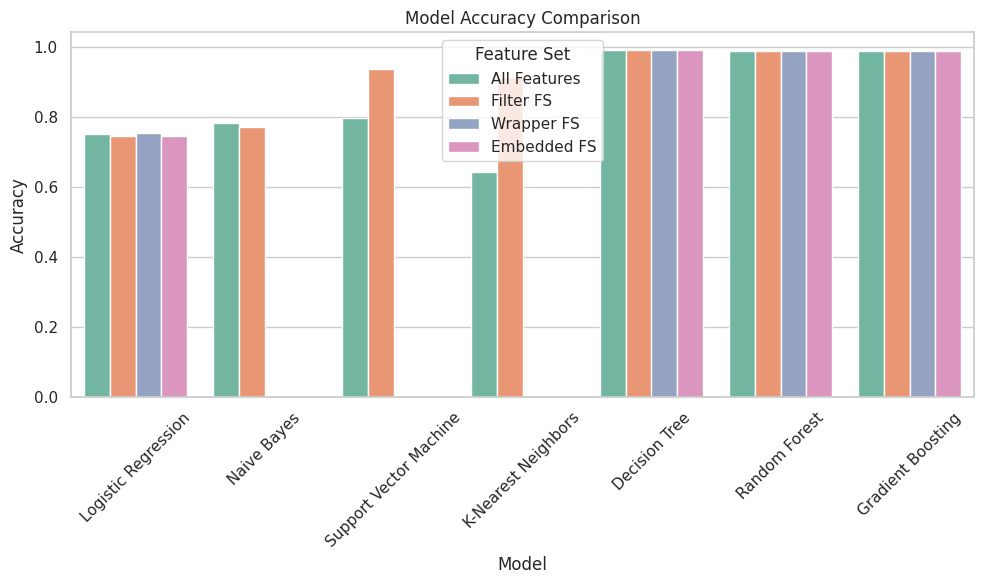

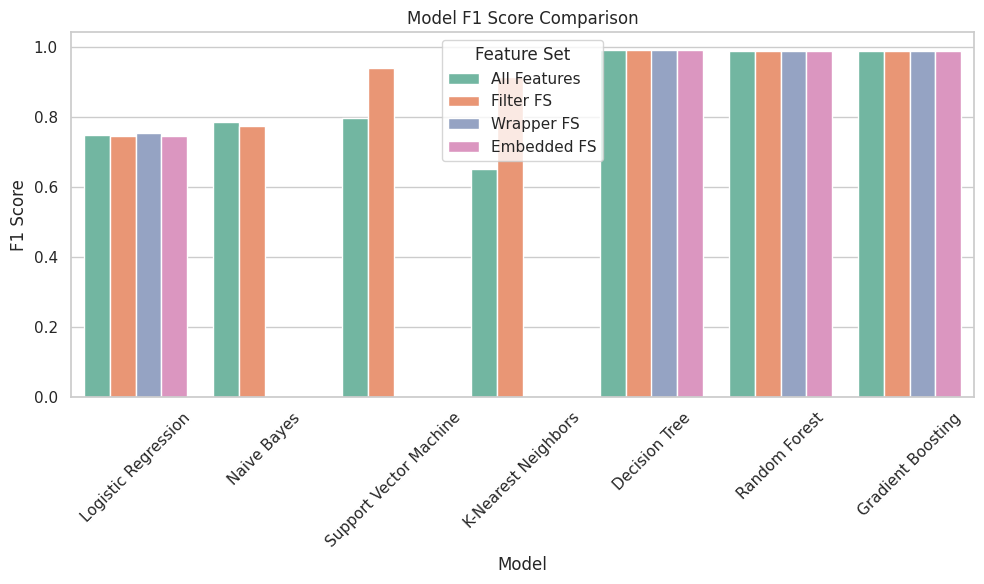

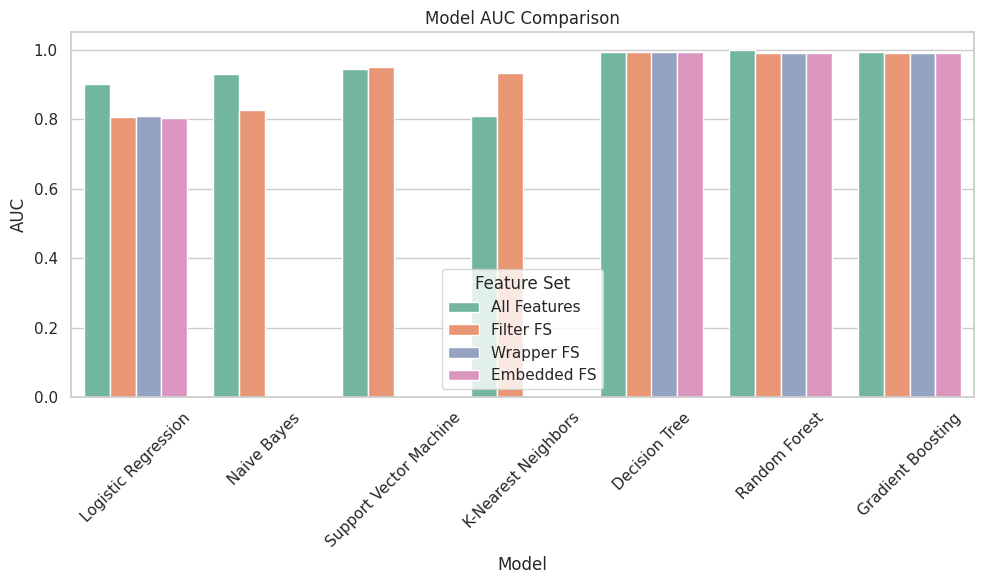

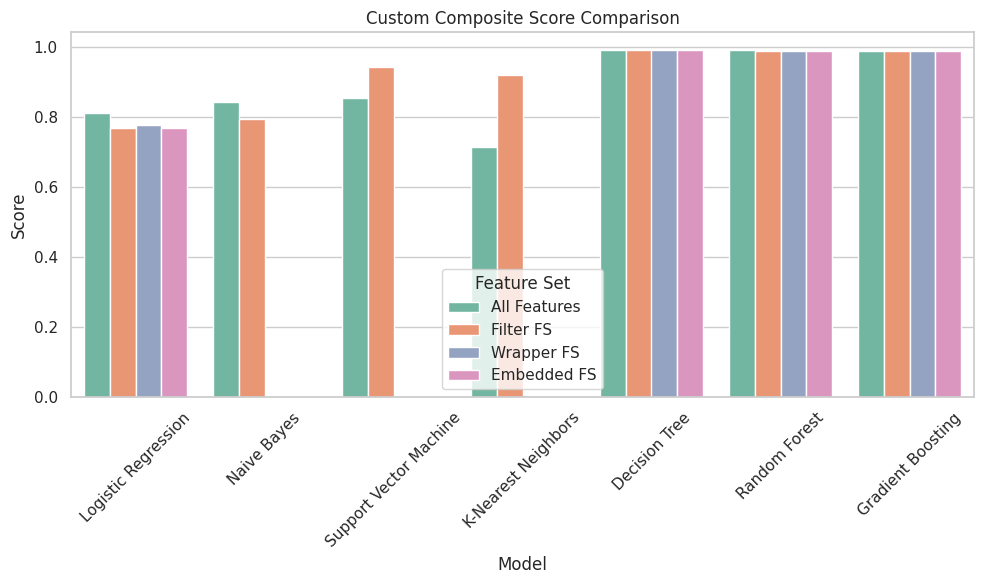

In [ ]:
# Imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif, RFE, SelectFromModel
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.exceptions import NotFittedError

# Initialize models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Naive Bayes": GaussianNB(),
    "Support Vector Machine": SVC(probability=True),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier()
}

# Feature scaling
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X.columns)

# === Full Feature Evaluation ===
model_metrics = []

for name, clf in models.items():
    clf.fit(X_train_scaled, y_train)
    y_pred = clf.predict(X_test_scaled)

    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    auc = roc_auc_score(y_test, clf.predict_proba(X_test_scaled), multi_class='ovr') if hasattr(clf, "predict_proba") else 0

    model_metrics.append({
        "Model": name,
        "Accuracy": accuracy,
        "F1 Score": f1,
        "AUC": auc
    })

# Compute full feature scores
for model in model_metrics:
    auc = model["AUC"] or 0
    f1 = model["F1 Score"]
    acc = model["Accuracy"]
    model["Score"] = 0.4 * auc + 0.4 * f1 + 0.2 * acc

# === Feature Selection Evaluation ===
fs_model_metrics = []

def evaluate_model_and_store(y_true, y_pred, clf_name, fs_method, selected_features):
    accuracy = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='weighted')
    try:
        auc = roc_auc_score(pd.get_dummies(y_true), pd.get_dummies(y_pred), multi_class='ovr')
    except:
        auc = 0

    fs_model_metrics.append({
        "Model": clf_name,
        "FS Method": fs_method,
        "Selected Features": selected_features,
        "Accuracy": accuracy,
        "F1 Score": f1,
        "AUC": auc,
        "Score": 0.4 * auc + 0.4 * f1 + 0.2 * accuracy
    })

# FS methods
def filter_method(X_train, y_train, X_test, k=3):
    selector = SelectKBest(score_func=f_classif, k=k)
    X_train_sel = selector.fit_transform(X_train, y_train)
    X_test_sel = selector.transform(X_test)
    return X_train_sel, X_test_sel, X_train.columns[selector.get_support()]

def wrapper_method(X_train, y_train, X_test, model, n_features=3):
    rfe = RFE(estimator=model, n_features_to_select=n_features)
    X_train_sel = rfe.fit_transform(X_train, y_train)
    X_test_sel = rfe.transform(X_test)
    return X_train_sel, X_test_sel, X_train.columns[rfe.get_support()]

rfe_compatible = ["Logistic Regression", "Decision Tree", "Random Forest", "Gradient Boosting"]

for clf_name, clf in models.items():
    # Filter
    X_train_f, X_test_f, sel_feat = filter_method(X_train_scaled, y_train, X_test_scaled)
    clf.fit(X_train_f, y_train)
    evaluate_model_and_store(y_test, clf.predict(X_test_f), clf_name, "Filter FS", sel_feat.tolist())

    # Wrapper
    if clf_name in rfe_compatible:
        try:
            X_train_w, X_test_w, sel_feat = wrapper_method(X_train_scaled, y_train, X_test_scaled, clf)
            clf.fit(X_train_w, y_train)
            evaluate_model_and_store(y_test, clf.predict(X_test_w), clf_name, "Wrapper FS", sel_feat.tolist())
        except ValueError:
            continue

    # Embedded
    try:
        clf.fit(X_train_scaled, y_train)
        if hasattr(clf, "feature_importances_"):
            importances = clf.feature_importances_
        elif hasattr(clf, "coef_"):
            importances = abs(clf.coef_).flatten()
        else:
            raise ValueError("No feature importance available")

        threshold = sorted(importances, reverse=True)[2]
        selector = SelectFromModel(clf, threshold=threshold, prefit=True)
        X_train_e = selector.transform(X_train_scaled)
        X_test_e = selector.transform(X_test_scaled)
        sel_feat = X_train.columns[selector.get_support()]

        clf.fit(X_train_e, y_train)
        evaluate_model_and_store(y_test, clf.predict(X_test_e), clf_name, "Embedded FS", sel_feat.tolist())
    except Exception:
        continue

# === Plotting ===
df_full = pd.DataFrame(model_metrics)
df_full['FS'] = 'All Features'
df_fs = pd.DataFrame(fs_model_metrics)
df_fs['FS'] = df_fs['FS Method']
df_combined = pd.concat([df_full, df_fs], ignore_index=True)

melted = df_combined.melt(id_vars=['Model', 'FS'],
                          value_vars=['Accuracy', 'F1 Score', 'AUC', 'Score'],
                          var_name='Metric', value_name='Value')

sns.set(style="whitegrid")
metrics = ['Accuracy', 'F1 Score', 'AUC', 'Score']
titles = {
    'Accuracy': 'Model Accuracy Comparison',
    'F1 Score': 'Model F1 Score Comparison',
    'AUC': 'Model AUC Comparison',
    'Score': 'Custom Composite Score Comparison'
}

for metric in metrics:
    plt.figure(figsize=(10, 6))
    sns.barplot(data=melted[melted['Metric'] == metric],
                x='Model', y='Value', hue='FS', palette='Set2')
    plt.title(titles[metric])
    plt.ylabel(metric)
    plt.xticks(rotation=45)
    plt.legend(title='Feature Set')
    plt.tight_layout()
    plt.show()
